# ISI-1 AUROC Method Comparison

d'(ISI=1) vs sigma1 shows a **non-monotonic bump** — d' increases before
decreasing — even after switching to the upper-envelope AUROC method.

This notebook runs the sigma1 sweep **once**, collects raw hit/FA scores,
then recomputes d' using **three different AUROC methods** on the same data:

| Method | Description |
|--------|-------------|
| `sklearn` | `roc_auc_score(y_true, -scores)` — standard full ROC |
| `upper-envelope` | Max TPR per unique FPR, anchor (0,0)/(1,1), 1000-pt interp, `eps=1e-4` |
| `sparse-12pt` | Old method: 12 target FPR points, closest-match, trapz |

If all three agree → the bump is genuine model behavior, not an AUROC artifact.

In [1]:
import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from scipy.spatial.distance import pdist
from sklearn.metrics import roc_auc_score, roc_curve

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from utls.plotting import ensure_dir
from utls.loading import (
    load_results_with_exclusion_2,
    move_sequences_to_used,
    load_results_with_exclusion_no_dropping,
)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from encoders import *

from utls.toy_experiments import (
    make_toy_experiment_list,
    make_compact_multi_isi_sequences,
    make_high_diversity_sequences,
    infer_trial_isis,
)
from utls.sigma_fitting import (
    log_mid,
    _compute_auroc_upper_envelope,
    auc_to_dprime,
)

try:
    get_ipython()
    from tqdm.notebook import tqdm, trange
except NameError:
    from tqdm import tqdm, trange

## 1. Load config & data

In [2]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path


CONFIG_PATH = (
    "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/"
    "model_yamls/three-regime/resnet50/nontime_avg/run_000005.yaml"
)

model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)

{'results_root': '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 3.0, 'sigma0_max': 0.5, 'sigma1_min': 0.1, 'sigma1_max': 0.6, 'sigma2_min': 0.0005, 'sigma2_max': 0.1, 't_step': 5}, 'run_id': 'run_000005', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': False}}


In [3]:
# ---- experiment ----
exp_cfg = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi = exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)

isis = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]

# ---- metric ----
metric = model_cfg["metric"]

# ---- noise model ----
noise_cfg = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step = noise_cfg["t_step"]

# ---- representation ----
repr_cfg = model_cfg["representation"]
time_avg = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer = repr_cfg.get("layer", None)
pc_dims = repr_cfg.get("pc_dims", None)

# ---- load human data ----
exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)

human_curve = compute_human_curve(human_runs, is_multi, which_isi)
print("ISIs:", isis)
print("Human d' curve:", human_curve)
print(f"Total real sequences: {len(exp_list)}")

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d' curve: [3.47682888 3.05209048 2.37335137 2.12136925 1.97836537 1.87979714
 1.720259   1.5833794 ]
Total real sequences: 104


## 2. Build encoder & encode stimuli

In [4]:
NN_ENCODERS = {"kell2018", "resnet50"}
encoder_task = (
    "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
)

encoder_cfg = dict(
    encoder_type=encoder_type,
    model_name=encoder_type,
    task=encoder_task,
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    pc_dims=pc_dims,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=time_avg,
    device="cuda",
)

if encoder_type in NN_ENCODERS:
    encoder_cfg["layer"] = layer
if encoder_type == "texture":
    encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
print("Encoder name:", encoder_name)

encoder = build_encoder(encoder_cfg)
X = encode_stimuli(encoder, all_files)
X_np = X.detach().cpu().numpy()
print("Encoded shape:", X_np.shape, "  any NaN?", torch.isnan(X).any().item())

Encoder name: resnet50-layer4
LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)


/orcd/data/jhm/001/om2/gelbanna/miniconda3/envs/asr312/lib/python3.12/site-packages/chcochleagram/downsampling.py:68: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608847532/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  x = ch.nn.functional.conv1d(x, self.downsample_filter,


Encoded shape: (80, 186368)   any NaN? False


## 3. Parameter bounds & stimulus pool

In [5]:
def median_pairwise_distance(X, metric="euclidean", n_samples=500, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=min(n_samples, X.shape[0]), replace=False)
    return float(np.median(pdist(X[idx], metric=metric)))


d50 = 1  # median_pairwise_distance(X_np, metric="cosine")
print(f"Median pairwise cosine distance: {d50:.6f}")

param_bounds = {
    "sigma0": (noise_cfg["sigma0_min"], 22),
    "sigma1": (0.01, 10 * d50),
    "sigma2": (noise_cfg["sigma2_min"] * d50, 0.5 * d50),
}

print("Parameter bounds:")
for k, v in param_bounds.items():
    print(f"  {k}: ({v[0]:.6f}, {v[1]:.6f})")

# Stimulus pool for sequence generation
stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"\nStimulus pool size: {len(stimulus_pool)}")

Median pairwise cosine distance: 1.000000
Parameter bounds:
  sigma0: (3.000000, 22.000000)
  sigma1: (0.010000, 10.000000)
  sigma2: (0.000500, 0.500000)

Stimulus pool size: 80


## 4. Human d' targets

In [6]:
isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}

sigma1_human = {isi: float(human_curve[isi_to_hc_idx[isi]]) for isi in [1, 2, 4]}

print("Stage B targets (sigma1):")
for isi, dp in sigma1_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

# Initial value for sigma2 (not being fitted)
sigma2_init = log_mid(*param_bounds["sigma2"])
print(f"\nFixed sigma2 = {sigma2_init:.6f}")

Stage B targets (sigma1):
  ISI 1: human d' = 3.0521
  ISI 2: human d' = 2.3734
  ISI 4: human d' = 2.1214

Fixed sigma2 = 0.015811


---
## 5. Define the three AUROC computation methods

In [7]:
def compute_dprime_sklearn(hits, fas):
    """Method 1: sklearn roc_auc_score (standard full ROC)."""
    hits, fas = np.asarray(hits), np.asarray(fas)
    if len(hits) == 0 or len(fas) == 0:
        return np.nan, np.nan
    y_true = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
    scores = np.concatenate([hits, fas])
    auroc = roc_auc_score(y_true, -scores)
    return float(auroc_to_dprime(auroc)), auroc


def compute_dprime_upper_envelope(hits, fas):
    """Method 2: Upper-envelope + dense 1000-pt interpolation (new method)."""
    auroc = _compute_auroc_upper_envelope(hits, fas)
    if np.isnan(auroc):
        return np.nan, np.nan
    return auc_to_dprime(auroc, eps=1e-4), auroc


def compute_dprime_sparse_sampled(hits, fas):
    """Method 3: Old sparse 12-point sampled ROC (replaced method)."""
    hits, fas = np.asarray(hits, dtype=float), np.asarray(fas, dtype=float)
    if len(hits) == 0 or len(fas) == 0:
        return np.nan, np.nan

    y_true = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
    scores = np.concatenate([hits, fas])
    P = (y_true == 1).sum()
    N = (y_true == 0).sum()

    thr = np.unique(np.sort(scores))
    tpr = np.array([(scores[y_true == 1] <= t).sum() / P for t in thr])
    fpr = np.array([(scores[y_true == 0] <= t).sum() / N for t in thr])

    target_fpr = np.array(
        [0.001, 0.0001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 0.99],
        dtype=float,
    )
    idx = np.unique([np.argmin(np.abs(fpr - f)) for f in target_fpr])
    fpr_s, tpr_s = fpr[idx], tpr[idx]
    order = np.argsort(fpr_s)
    auroc = float(np.trapz(tpr_s[order], fpr_s[order]))
    return auc_to_dprime(auroc), auroc


METHODS = {
    "sklearn": compute_dprime_sklearn,
    "upper-envelope": compute_dprime_upper_envelope,
    "sparse-12pt": compute_dprime_sparse_sampled,
}
print("Methods defined:", list(METHODS.keys()))

Methods defined: ['sklearn', 'upper-envelope', 'sparse-12pt']


---
## 6. Sweep function (collects raw scores)

In [8]:
def sweep_sigma1_detailed(
    sigma1_value, sigma0, sigma2, t_step,
    noise_mode, metric, X0, name_to_idx,
    experiment_list, target_isis,
    human_dprimes_by_isi=None,
    n_mc=64, seed=0,
):
    """
    Evaluate a single sigma1 value and return raw hit/FA scores
    for post-hoc AUROC method comparison.
    """
    seq_trial_isis = [infer_trial_isis(seq) for seq in experiment_list]

    all_hits_by_isi = {isi: [] for isi in target_isis}
    all_fas = []

    for rep in range(n_mc):
        for si, seq in enumerate(experiment_list):
            t_isis = seq_trial_isis[si]
            run_out = run_experiment_scores(
                sigma0=sigma0,
                sigma1=sigma1_value,
                sigma2=sigma2,
                t_step=t_step,
                rate=0,
                noise_mode=noise_mode,
                metric=metric,
                X0=X0,
                name_to_idx=name_to_idx,
                experiment_list=[seq],
                debug=False,
                seed=seed + rep * 1000 + si,
            )
            h = np.asarray(run_out["hits"])
            f = np.asarray(run_out["fas"])
            if len(h) != len(t_isis):
                continue
            for isi_val in target_isis:
                mask = np.array(t_isis) == isi_val
                all_hits_by_isi[isi_val].extend(h[mask].tolist())
            all_fas.extend(f.tolist())

    fas_arr = np.array(all_fas)

    return {
        "sigma1": sigma1_value,
        "hit_scores_by_isi": {isi: np.array(v) for isi, v in all_hits_by_isi.items()},
        "fa_scores": fas_arr,
        "n_hits_by_isi": {isi: len(v) for isi, v in all_hits_by_isi.items()},
        "n_fas": len(fas_arr),
    }


def run_sigma1_sweep(
    sigma0, sigma1_grid, sigma2, t_step,
    experiment_list, target_isis,
    human_dprimes_by_isi,
    noise_mode, metric, X0, name_to_idx,
    n_mc=64, seed=0, desc="sigma1 sweep",
):
    """Run sweep_sigma1_detailed for each sigma1 in the grid."""
    results = []
    for i in trange(len(sigma1_grid), desc=desc):
        r = sweep_sigma1_detailed(
            sigma1_value=sigma1_grid[i],
            sigma0=sigma0,
            sigma2=sigma2,
            t_step=t_step,
            noise_mode=noise_mode,
            metric=metric,
            X0=X0,
            name_to_idx=name_to_idx,
            experiment_list=experiment_list,
            target_isis=target_isis,
            human_dprimes_by_isi=human_dprimes_by_isi,
            n_mc=n_mc,
            seed=seed + i * 100_000,
        )
        results.append(r)
    return results

In [9]:
def recompute_dprime_all_methods(sweep_results, target_isi=1):
    """Recompute d' from raw scores using all 3 AUROC methods."""
    out = {name: {"dprime": [], "auroc": []} for name in METHODS}
    sigma1_vals = []
    for r in sweep_results:
        sigma1_vals.append(r["sigma1"])
        hits = r["hit_scores_by_isi"][target_isi]
        fas = r["fa_scores"]
        for name, fn in METHODS.items():
            dp, auc = fn(hits, fas)
            out[name]["dprime"].append(dp)
            out[name]["auroc"].append(auc)
    return np.array(sigma1_vals), out


print("Recompute function ready.")

Recompute function ready.


---
## 7. Generate ISI=[1]-only sequences & run sweeps

In [10]:
# Generate ISI=[1]-only compact sequences
ISI1_EXPS, ISI1_ISI_KEYS = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=[1],
    n_sequences=8,
    length=60,
    min_pairs_per_isi=5,
    seed=1000,
)
print(f"Generated {len(ISI1_EXPS)} ISI=[1] sequences, {len(ISI1_EXPS[0])} trials each")

for seq in ISI1_EXPS:
    counts = Counter(infer_trial_isis(seq))
    print(f"  ISI=1 pairs: {counts.get(1, 0)}")

Aggregate ISI usage across all sequences:
  ISI -1: 160
  ISI 1: 320
Generated 8 ISI=[1] sequences, 60 trials each
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20


In [15]:
# --- sigma1 grid ---
n_grid = 5
SIGMA1_GRID = np.exp(np.linspace(np.log(0.9), np.log(15.0), n_grid))
N_MC = 12

print(f"Sigma1 grid: {len(SIGMA1_GRID)} points, range [{SIGMA1_GRID[0]:.4f}, {SIGMA1_GRID[-1]:.4f}]")

# --- Sweep for each sigma0 ---
SIGMA0_VALUES = [8, 10, 12]

sweep_by_sigma0 = {}
for s0 in SIGMA0_VALUES:
    print(f"\n--- sigma0 = {s0} ---")
    sweep_by_sigma0[s0] = run_sigma1_sweep(
        sigma0=s0, sigma1_grid=SIGMA1_GRID, sigma2=sigma2_init,
        t_step=t_step, experiment_list=ISI1_EXPS,
        target_isis=[1], human_dprimes_by_isi=sigma1_human,
        noise_mode=noise_mode, metric=metric,
        X0=X, name_to_idx=name_to_idx,
        n_mc=N_MC, seed=int(200_000 * s0),
        desc=f"sigma0={s0}",
    )

print("\nAll sweeps done.")

Sigma1 grid: 5 points, range [0.9000, 15.0000]

--- sigma0 = 8 ---


sigma0=8:   0%|          | 0/5 [00:00<?, ?it/s]


--- sigma0 = 10 ---


sigma0=10:   0%|          | 0/5 [00:00<?, ?it/s]


--- sigma0 = 12 ---


sigma0=12:   0%|          | 0/5 [00:00<?, ?it/s]


All sweeps done.


---
## 8. d' vs sigma1 — all 3 methods overlaid

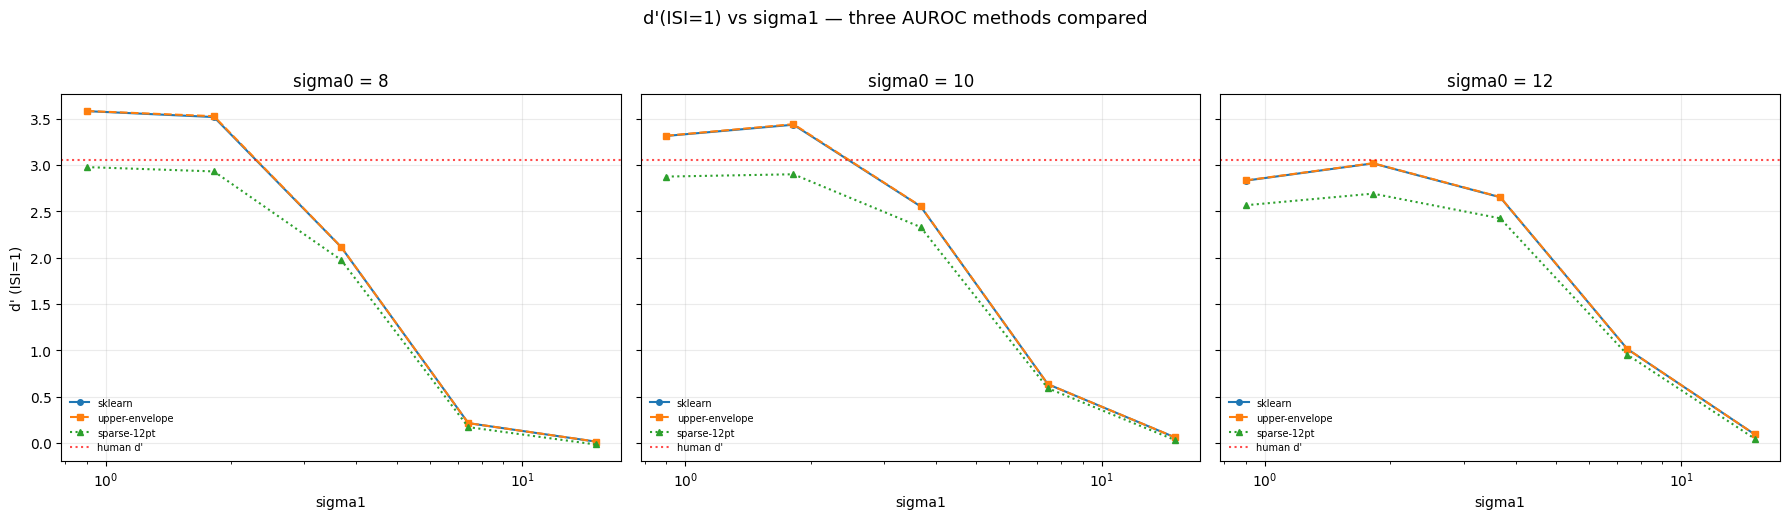

In [16]:
METHOD_STYLES = {
    "sklearn":        {"ls": "-",  "marker": "o", "color": "tab:blue"},
    "upper-envelope": {"ls": "--", "marker": "s", "color": "tab:orange"},
    "sparse-12pt":    {"ls": ":",  "marker": "^", "color": "tab:green"},
}

fig, axes = plt.subplots(1, len(SIGMA0_VALUES), figsize=(6 * len(SIGMA0_VALUES), 5),
                         sharey=True)
if len(SIGMA0_VALUES) == 1:
    axes = [axes]

for ax, s0 in zip(axes, SIGMA0_VALUES):
    s1_vals, method_data = recompute_dprime_all_methods(sweep_by_sigma0[s0], target_isi=1)

    for name, style in METHOD_STYLES.items():
        ax.plot(s1_vals, method_data[name]["dprime"],
                ls=style["ls"], marker=style["marker"], ms=4,
                color=style["color"], label=name)

    ax.axhline(sigma1_human[1], ls=":", color="red", alpha=0.7, label="human d'")
    ax.set_xscale("log")
    ax.set_xlabel("sigma1")
    ax.set_title(f"sigma0 = {s0}")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, frameon=False)

axes[0].set_ylabel("d' (ISI=1)")
fig.suptitle("d'(ISI=1) vs sigma1 — three AUROC methods compared", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

---
## 9. AUROC vs sigma1 — all 3 methods overlaid

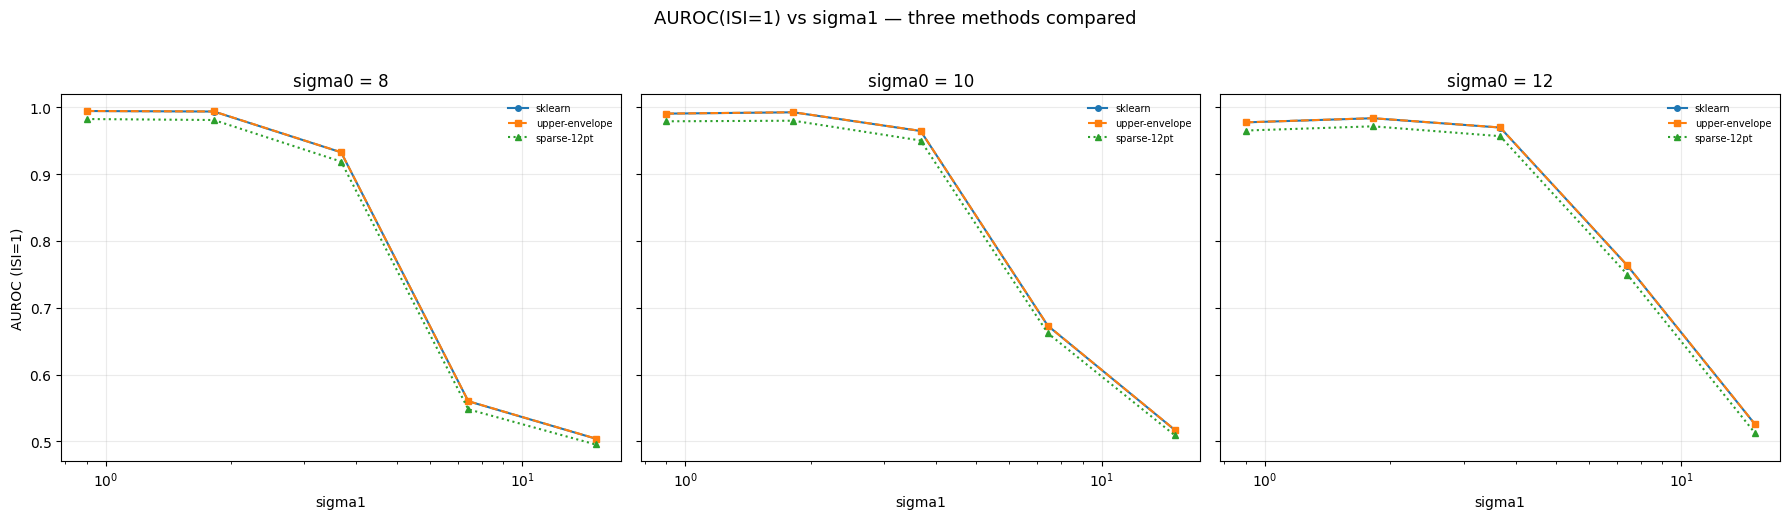

In [17]:
fig, axes = plt.subplots(1, len(SIGMA0_VALUES), figsize=(6 * len(SIGMA0_VALUES), 5),
                         sharey=True)
if len(SIGMA0_VALUES) == 1:
    axes = [axes]

for ax, s0 in zip(axes, SIGMA0_VALUES):
    s1_vals, method_data = recompute_dprime_all_methods(sweep_by_sigma0[s0], target_isi=1)

    for name, style in METHOD_STYLES.items():
        ax.plot(s1_vals, method_data[name]["auroc"],
                ls=style["ls"], marker=style["marker"], ms=4,
                color=style["color"], label=name)

    ax.set_xscale("log")
    ax.set_xlabel("sigma1")
    ax.set_title(f"sigma0 = {s0}")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, frameon=False)

axes[0].set_ylabel("AUROC (ISI=1)")
fig.suptitle("AUROC(ISI=1) vs sigma1 — three methods compared", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

---
## 10. Method differences: d'(sklearn) minus others

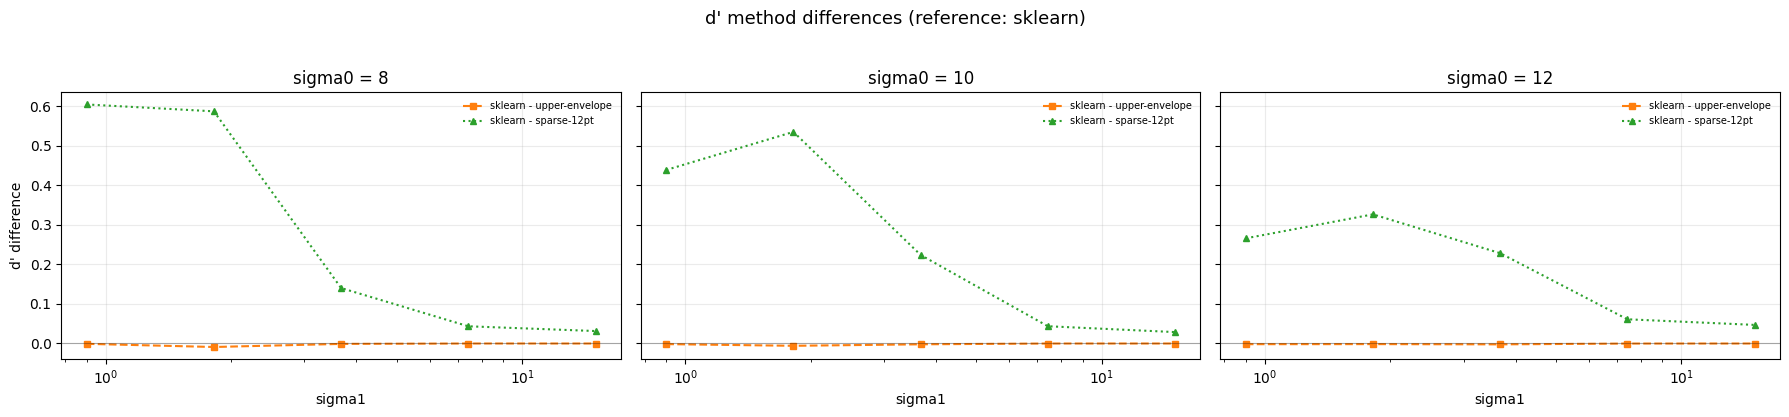

In [18]:
fig, axes = plt.subplots(1, len(SIGMA0_VALUES), figsize=(6 * len(SIGMA0_VALUES), 4),
                         sharey=True)
if len(SIGMA0_VALUES) == 1:
    axes = [axes]

for ax, s0 in zip(axes, SIGMA0_VALUES):
    s1_vals, method_data = recompute_dprime_all_methods(sweep_by_sigma0[s0], target_isi=1)

    dp_sklearn = np.array(method_data["sklearn"]["dprime"])
    dp_ue = np.array(method_data["upper-envelope"]["dprime"])
    dp_sp = np.array(method_data["sparse-12pt"]["dprime"])

    ax.plot(s1_vals, dp_sklearn - dp_ue, "s--", ms=4,
            color="tab:orange", label="sklearn - upper-envelope")
    ax.plot(s1_vals, dp_sklearn - dp_sp, "^:", ms=4,
            color="tab:green", label="sklearn - sparse-12pt")
    ax.axhline(0, color="k", alpha=0.3, lw=0.8)

    ax.set_xscale("log")
    ax.set_xlabel("sigma1")
    ax.set_title(f"sigma0 = {s0}")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, frameon=False)

axes[0].set_ylabel("d' difference")
fig.suptitle("d' method differences (reference: sklearn)", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

---
## 11. Summary

**Conclusions** (fill in after running):

- If all three methods show the same nonmonotonic bump → the bump is **genuine model behavior**, not an AUROC computation artifact.
- If the sparse-12pt method shows the bump but sklearn/upper-envelope don't → the old method was the culprit.
- If upper-envelope diverges from sklearn → investigate the interpolation/envelope procedure.